Mounted at /content/drive
Dataset cargado: 14127 registros.
Entrenando Random Forest...

--- Random Forest ---
              precision    recall  f1-score   support

        Apto       0.67      0.73      0.70      1466
     No Apto       0.68      0.62      0.64      1360

    accuracy                           0.67      2826
   macro avg       0.67      0.67      0.67      2826
weighted avg       0.67      0.67      0.67      2826

Entrenando XGBoost...

--- XGBoost ---
              precision    recall  f1-score   support

        Apto       0.68      0.74      0.71      1466
     No Apto       0.69      0.63      0.66      1360

    accuracy                           0.69      2826
   macro avg       0.69      0.69      0.69      2826
weighted avg       0.69      0.69      0.69      2826

Entrenando Logistic Regression...

--- Logistic Regression ---
              precision    recall  f1-score   support

        Apto       0.53      0.72      0.61      1466
     No Apto       0.50 

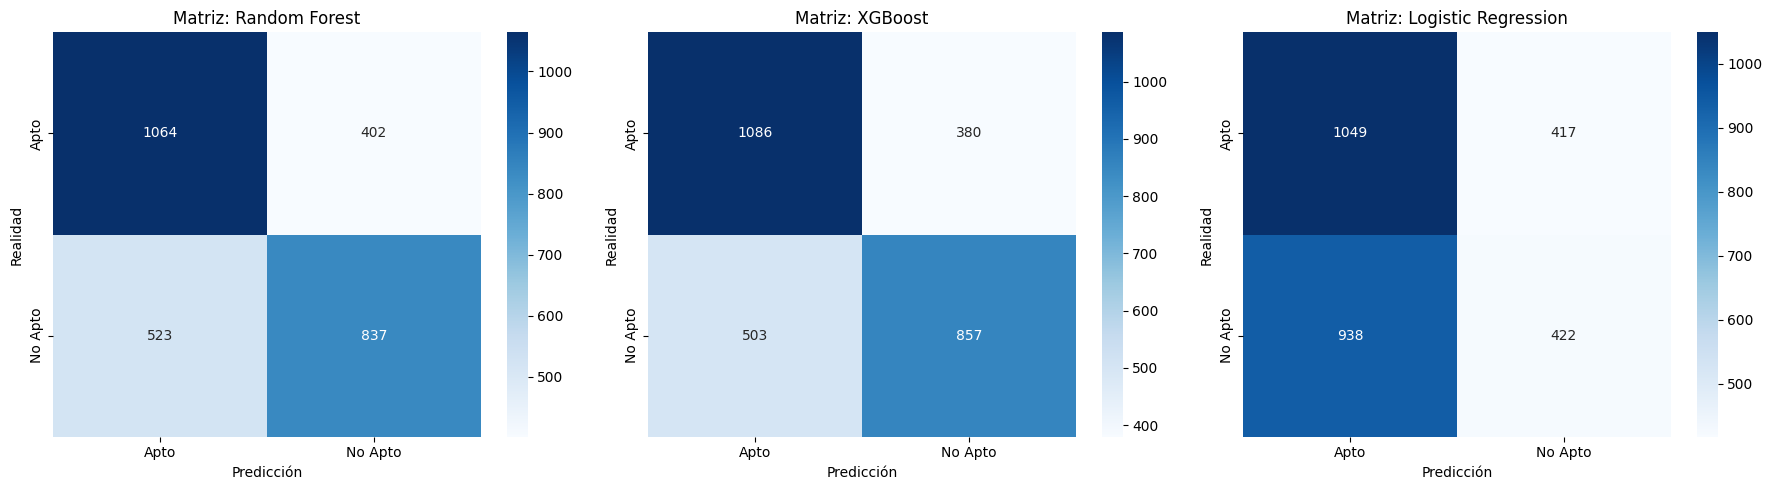


COMPARATIVA DE PRECISIÓN (ACCURACY)
Random Forest: 0.6727
XGBoost: 0.6875
Logistic Regression: 0.5205

Modelo ganador guardado en: /content/drive/MyDrive/Seminario de Tesis 1/mejor_modelo_somnolencia.pkl


In [1]:
# ==============================================================================
# CONFIGURACIÓN INICIAL Y CARGA DE DATOS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import drive

# Modelos y Métricas
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Montar Drive
drive.mount('/content/drive')

# Cargar dataset (ajusta la ruta si es necesario)
ruta_csv = '/content/drive/MyDrive/Seminario de Tesis 1/data.csv'
df = pd.read_csv(ruta_csv)
print(f"Dataset cargado: {len(df)} registros.")

# ==============================================================================
# PREPARACIÓN DE DATOS (FEATURE ENGINEERING)
# ==============================================================================
# Limpieza y binarización (Apto = 0, No Apto = 1)
df = df.dropna(subset=['Label'])
mapeo_binario = {'H': 0, 'N': 0, 'M': 1, 'L': 1}
df['Target'] = df['Label'].map(mapeo_binario)
df = df.sort_values(by='timestamp')

# Extracción de tendencias dinámicas (Ventana de 1 segundo a 20 FPS)
df['EAR_mean_1s'] = df['EAR'].rolling(window=20, min_periods=1).mean()
df['EAR_std_1s'] = df['EAR'].rolling(window=20, min_periods=1).std()
df['MAR_mean_1s'] = df['MAR'].rolling(window=20, min_periods=1).mean()

df = df.dropna()

# Selección de variables
X = df[['EAR', 'MAR', 'EAR_mean_1s', 'EAR_std_1s', 'MAR_mean_1s']]
y = df['Target']

# División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==============================================================================
# ENTRENAMIENTO Y COMPARACIÓN DE MODELOS
# ==============================================================================
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='logloss'),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

resultados = {}

# Crear figura para matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nombre, modelo) in enumerate(modelos.items()):
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train, y_train)

    # Predicción y Evaluación
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc

    # Reporte en consola
    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, y_pred, target_names=['Apto', 'No Apto']))

    # Matriz de Confusión Visual
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Apto', 'No Apto'], yticklabels=['Apto', 'No Apto'])
    axes[i].set_title(f'Matriz: {nombre}')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

# ==============================================================================
# RESUMEN FINAL Y EXPORTACIÓN
# ==============================================================================
print("\n" + "="*40)
print("COMPARATIVA DE PRECISIÓN (ACCURACY)")
print("="*40)
for mod, score in resultados.items():
    print(f"{mod}: {score:.4f}")

# Guardar el mejor modelo (ejemplo con XGBoost por ser el ganador previo)
ruta_save = '/content/drive/MyDrive/Seminario de Tesis 1/mejor_modelo_somnolencia.pkl'
joblib.dump(modelos["XGBoost"], ruta_save)
print(f"\nModelo ganador guardado en: {ruta_save}")